# 05 OutlierHandling

Notebook for outlier analysis and outlier removal from featured data.

In [15]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.paths import INTERIM_DATA_DIR

sns.set_theme(style='whitegrid')
INTERIM_DATA_DIR

WindowsPath('D:/ML/data/interim')

## Load Featured Data

Load data from `04_FeatureEngineering.ipynb` output.

In [16]:
source_path = INTERIM_DATA_DIR / 'vw_timestamp_dashboard_featured.csv'
df_feature = pd.read_csv(source_path)

print(f'source: {source_path}')
print(f'shape: {df_feature.shape}')
df_feature.head()

source: D:\ML\data\interim\vw_timestamp_dashboard_featured.csv
shape: (7519, 55)


,PlantName,PickListType,PickDate,TruckSeqNo,CarType,CarNo,PackListNo,CustomerName,QueueTime,PrepareForward,...,wait_call_min,prepare_loading_min,loading_time_min,close_job_min,total_time_min,has_tile,has_fitting,has_accessories,product_group_count,total_sap_amount
0,SB1,Walk in,2026-04-10 08:52:23,1,4 ล้อ,84-5388,SB1PL260410015,หจก.สำรวยเซรามิค,2026-04-10 08:52:32,N,...,15.63,1.40,12.02,24.33,53.38,1,1,0,2,1647.0
1,SB1,Walk in,2026-04-10 08:48:55,4,6 ล้อ,70-4573,SB1PL260410014,บริษัท วันโฮม วัสดุก่อสร้าง จำกัด,2026-04-10 08:49:00,N,...,7.95,2.72,6.23,10.80,27.70,1,0,0,1,1600.0
2,SB1,Walk in,2026-04-10 08:47:25,1,4 ล้อ,3ฒอ9423,SB1PL260410013,บ.รวมซีเมนต์99 จก.,2026-04-10 08:47:34,N,...,9.62,13.63,7.10,19.32,49.67,1,1,1,3,571.0
3,SB1,Walk in,2026-04-10 08:42:51,2,4 ล้อ,บล4874,SB1PL260410012,บ.เงินทองมาวัสดุ จก.,2026-04-10 08:42:56,N,...,1.58,10.43,15.42,8.12,35.55,1,1,0,2,290.0
4,SB1,Walk in,2026-04-10 08:29:57,6,6 ล้อ,71-0658,SB1PL260410011,บริษัท วันโฮม วัสดุก่อสร้าง จำกัด,2026-04-10 08:30:02,N,...,5.40,4.67,9.88,13.87,33.82,1,0,0,1,1600.0


## Outlier Analysis

In [17]:
target_columns = [
    'wait_call_min',
    'prepare_loading_min',
    'loading_time_min',
    'close_job_min',
    'total_time_min',
]

percentile_summary = df_feature[target_columns].quantile([0.90, 0.95, 0.99]).T
percentile_summary.columns = ['p90', 'p95', 'p99']
percentile_summary

,p90,p95,p99
wait_call_min,21.284,28.820,49.1874
prepare_loading_min,24.750,32.253,50.7940
loading_time_min,56.238,69.782,90.8512
close_job_min,29.534,38.080,62.7156
total_time_min,97.030,106.152,125.8550


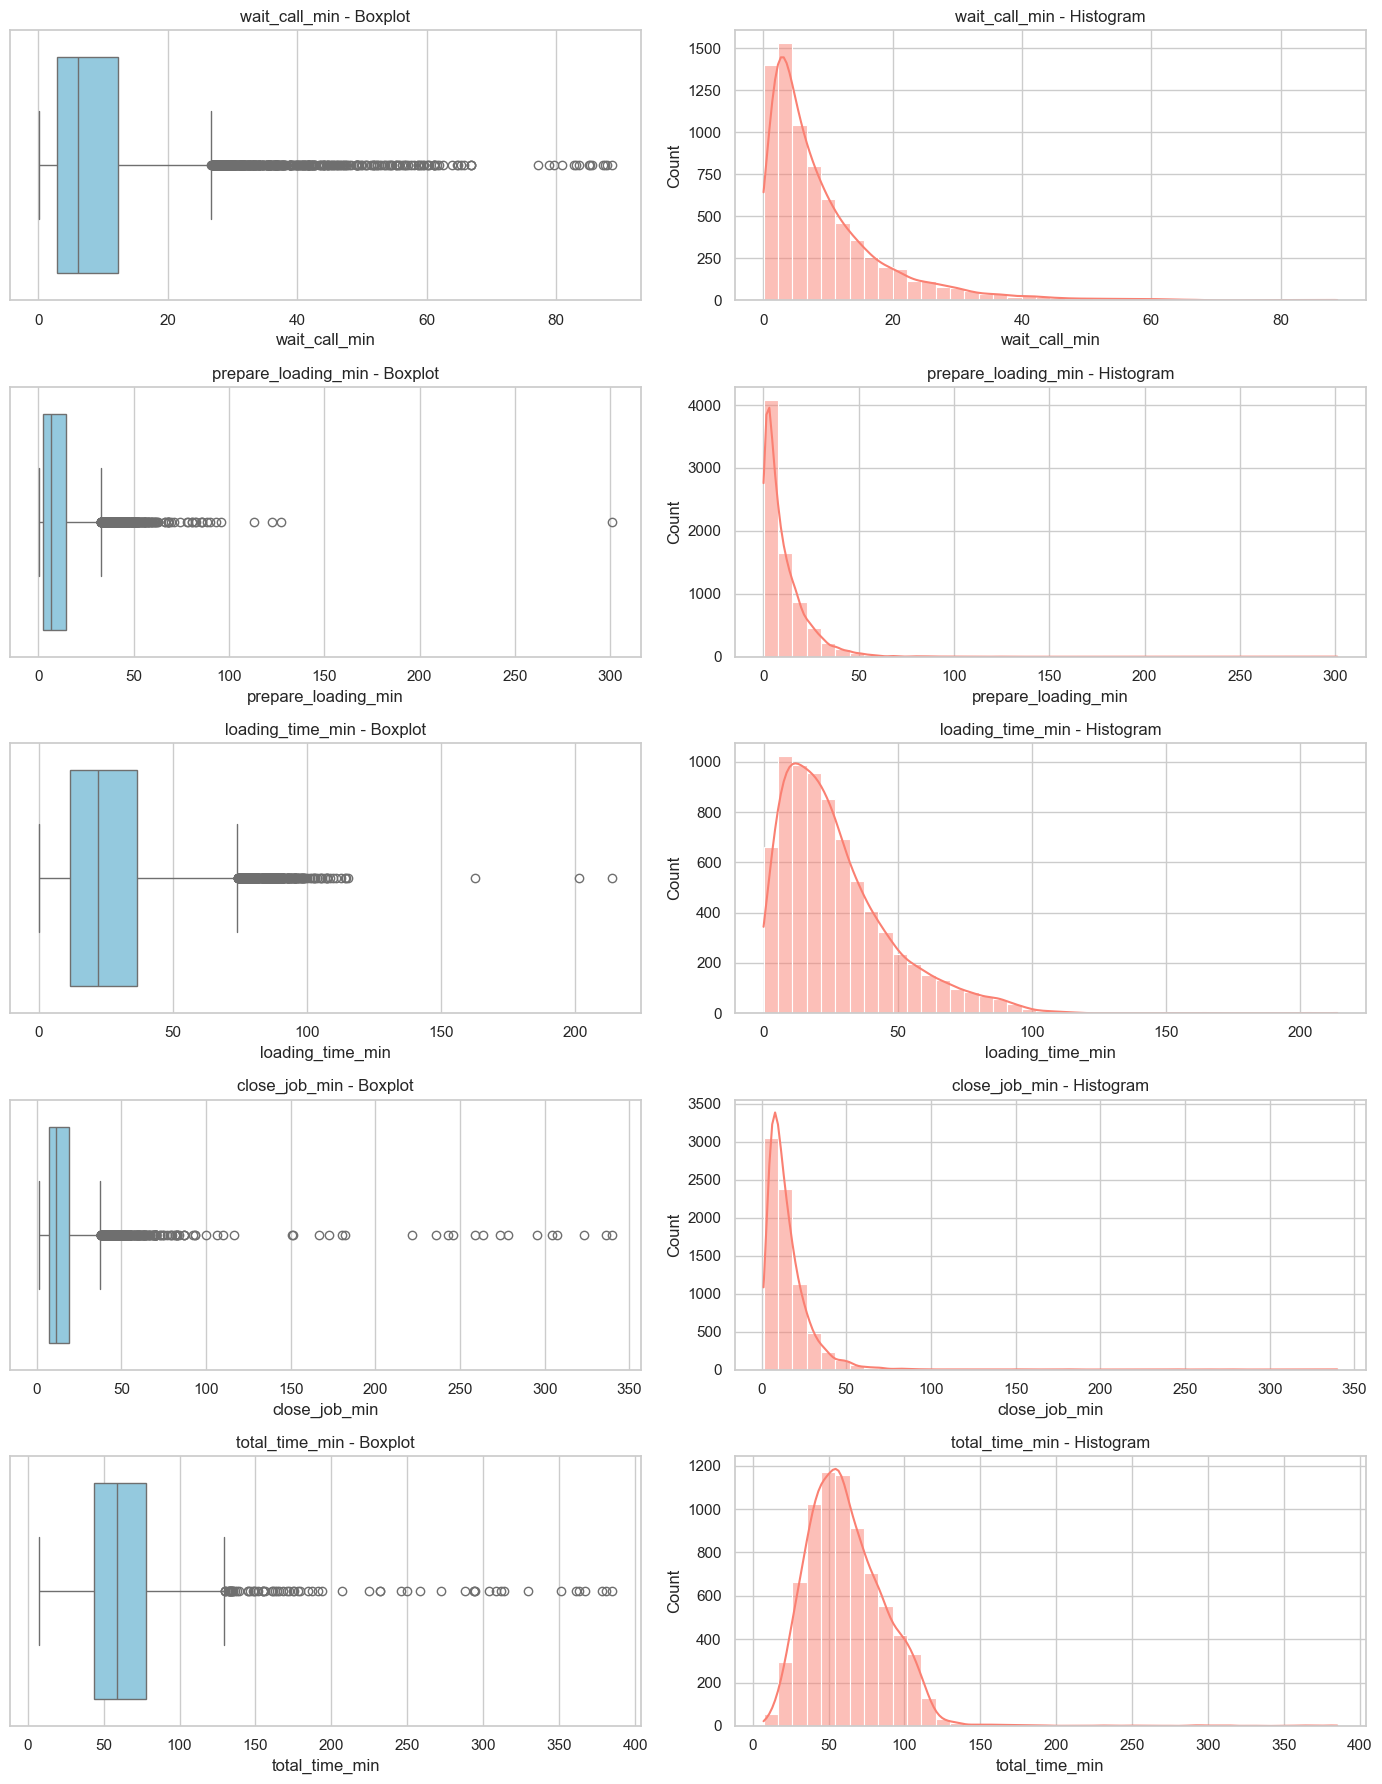

In [18]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 18))

for idx, col in enumerate(target_columns):
    sns.boxplot(x=df_feature[col], ax=axes[idx, 0], color='skyblue')
    axes[idx, 0].set_title(f'{col} - Boxplot')
    axes[idx, 0].set_xlabel(col)

    sns.histplot(df_feature[col], bins=40, kde=True, ax=axes[idx, 1], color='salmon')
    axes[idx, 1].set_title(f'{col} - Histogram')
    axes[idx, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

In [19]:
id_columns = [
    'PackListNo',
    'CarType',
    'PickListType',
    'OperatorCarConfirm',
    'CarConfirm',
    'FirstPostPallet',
    'LastPostPallet',
    'PostingTime',
]

for col in target_columns:
    print(f'\nTop 10 rows for {col}')
    display_cols = id_columns + [col]
    display(df_feature.sort_values(col, ascending=False)[display_cols].head(10))


Top 10 rows for wait_call_min


,PackListNo,CarType,PickListType,OperatorCarConfirm,CarConfirm,FirstPostPallet,LastPostPallet,PostingTime,wait_call_min
4539,SB1PL260126070,6 ล้อ,Walk in,2026-01-26 14:50:58,2026-01-26 16:19:42,2026-01-26 16:33:20,2026-01-26 16:44:52,2026-01-26 16:47:47,88.73
4535,SB1PL260126076,6 ล้อ,Walk in,2026-01-26 15:23:38,2026-01-26 16:51:34,2026-01-26 16:54:59,2026-01-26 17:05:57,2026-01-26 17:09:58,87.93
4540,SB1PL260126069,6 ล้อ,Walk in,2026-01-26 14:47:42,2026-01-26 16:15:16,2026-01-26 16:24:47,2026-01-26 16:34:10,2026-01-26 16:39:24,87.57
5169,SB1PL260113063,เทรเลอร์,Walk in,2026-01-13 14:29:53,2026-01-13 15:57:09,2026-01-13 16:13:39,2026-01-13 17:33:59,2026-01-13 17:43:36,87.27
887,SB1PL260327096,6 ล้อ,ล่วงหน้า,2026-03-28 13:03:44,2026-03-28 14:29:16,2026-03-28 14:30:24,2026-03-28 14:32:48,2026-03-28 14:38:40,85.53
7129,SB1PL251117029,6 ล้อ,ล่วงหน้า,2025-11-17 13:31:09,2025-11-17 14:56:26,2025-11-17 14:56:33,2025-11-17 14:58:14,2025-11-17 15:02:38,85.28
4832,SB1PL260120063,6 ล้อ,Walk in,2026-01-20 15:16:36,2026-01-20 16:41:44,2026-01-20 16:42:00,2026-01-20 16:48:20,2026-01-20 16:57:46,85.13
326,SB1PL260403110,เทรเลอร์,ล่วงหน้า,2026-04-06 08:02:59,2026-04-06 09:26:33,2026-04-06 09:56:39,2026-04-06 10:15:00,2026-04-06 10:20:55,83.57
5176,SB1PL260113049,เทรเลอร์,Walk in,2026-01-13 13:02:13,2026-01-13 14:25:16,2026-01-13 14:42:28,2026-01-13 15:59:39,2026-01-13 16:06:33,83.05
6184,SB1PL251203059,6 ล้อ,Walk in,2025-12-03 15:29:02,2025-12-03 16:51:54,2025-12-03 16:53:56,2025-12-03 17:13:12,2025-12-03 17:24:06,82.87



Top 10 rows for prepare_loading_min


,PackListNo,CarType,PickListType,OperatorCarConfirm,CarConfirm,FirstPostPallet,LastPostPallet,PostingTime,prepare_loading_min
516,SB1PL260402114,เทรเลอร์,ล่วงหน้า,2026-04-03 07:44:51,2026-04-03 07:48:42,2026-04-03 12:49:47,2026-04-03 13:04:41,2026-04-03 13:14:26,301.08
5183,SB1PL260113037,เทรเลอร์,Walk in,2026-01-13 11:28:00,2026-01-13 11:32:08,2026-01-13 13:39:17,2026-01-13 14:27:51,2026-01-13 15:19:55,127.15
571,SB1PL260331098,เทรเลอร์,ล่วงหน้า,2026-04-02 12:21:51,2026-04-02 12:30:21,2026-04-02 14:32:42,2026-04-02 15:05:52,2026-04-02 15:14:11,122.35
4719,SB1PL260122026,6 ล้อ,Walk in,2026-01-22 10:57:52,2026-01-22 11:05:56,2026-01-22 12:58:46,2026-01-22 13:16:43,2026-01-22 13:33:06,112.83
5026,SB1PL260115063,เทรเลอร์,ล่วงหน้า,2026-01-16 11:27:43,2026-01-16 11:31:00,2026-01-16 13:06:52,2026-01-16 13:21:26,2026-01-16 13:29:31,95.87
2895,SB1PL260219102,เทรเลอร์,ล่วงหน้า,2026-02-24 07:32:24,2026-02-24 07:35:06,2026-02-24 09:08:08,2026-02-24 09:18:31,2026-02-24 09:20:13,93.03
719,SB1PL260331064,6 ล้อ,Walk in,2026-03-31 15:16:04,2026-03-31 15:26:49,2026-03-31 16:57:00,2026-03-31 17:02:25,2026-03-31 17:06:36,90.18
4720,SB1PL260122025,6 ล้อ,Walk in,2026-01-22 10:45:20,2026-01-22 11:05:46,2026-01-22 12:34:11,2026-01-22 12:48:54,2026-01-22 12:59:48,88.42
4760,SB1PL260121077,6 ล้อ,Walk in,2026-01-21 15:21:06,2026-01-21 15:38:27,2026-01-21 17:04:13,2026-01-21 17:07:29,2026-01-21 17:18:59,85.77
4721,SB1PL260122024,6 ล้อ,Walk in,2026-01-22 10:42:06,2026-01-22 11:06:13,2026-01-22 12:31:46,2026-01-22 12:44:51,2026-01-22 12:57:14,85.55



Top 10 rows for loading_time_min


,PackListNo,CarType,PickListType,OperatorCarConfirm,CarConfirm,FirstPostPallet,LastPostPallet,PostingTime,loading_time_min
479,SB1PL260402109,เทรเลอร์,ล่วงหน้า,2026-04-03 11:37:27,2026-04-03 11:57:57,2026-04-03 12:19:39,2026-04-03 15:53:38,2026-04-03 16:09:32,213.98
5163,SB1PL260113072,เทรเลอร์,Walk in,2026-01-13 15:15:09,2026-01-13 15:23:32,2026-01-13 15:25:38,2026-01-13 18:47:15,2026-01-13 19:07:10,201.62
498,SB1PL260403023,เทรเลอร์,Walk in,2026-04-03 09:53:28,2026-04-03 10:01:41,2026-04-03 10:51:47,2026-04-03 13:34:28,2026-04-03 13:59:12,162.68
1547,SB1PL260318094,เทรเลอร์,SmartQ,2026-03-18 17:35:57,2026-03-18 17:37:49,2026-03-18 17:40:27,2026-03-18 19:35:58,2026-03-18 19:44:49,115.52
555,SB1PL260402056,เทรเลอร์,Walk in,2026-04-02 14:37:38,2026-04-02 14:44:47,2026-04-02 14:58:46,2026-04-02 16:53:20,2026-04-02 17:02:33,114.57
1425,SB1PL260319110,เทรเลอร์,ล่วงหน้า,2026-03-20 10:35:18,2026-03-20 10:36:59,2026-03-20 10:43:38,2026-03-20 12:38:04,2026-03-20 12:48:38,114.43
5114,SB1PL260114053,เทรเลอร์,ล่วงหน้า,2026-01-14 14:52:40,2026-01-14 14:54:49,2026-01-14 14:55:31,2026-01-14 16:48:23,2026-01-14 16:53:23,112.87
3956,SB1PL260206022,เทรเลอร์,ล่วงหน้า,2026-02-06 10:56:32,2026-02-06 10:59:11,2026-02-06 11:04:46,2026-02-06 12:55:33,2026-02-06 12:59:03,110.78
2878,SB1PL260219105,เทรเลอร์,ล่วงหน้า,2026-02-24 10:55:27,2026-02-24 10:57:17,2026-02-24 10:59:26,2026-02-24 12:49:22,2026-02-24 12:52:08,109.93
5228,SB1PL251219026,เทรเลอร์,ล่วงหน้า,2025-12-19 10:13:51,2025-12-19 10:16:22,2025-12-19 10:18:46,2025-12-19 12:07:28,2025-12-19 12:12:19,108.70



Top 10 rows for close_job_min


,PackListNo,CarType,PickListType,OperatorCarConfirm,CarConfirm,FirstPostPallet,LastPostPallet,PostingTime,close_job_min
5209,SB1PL260112075,6 ล้อ,ล่วงหน้า,2026-01-13 07:17:57,2026-01-13 07:44:34,2026-01-13 07:52:05,2026-01-13 07:56:08,2026-01-13 13:36:02,339.90
5206,SB1PL260113005,6 ล้อ,Walk in,2026-01-13 07:40:30,2026-01-13 07:53:51,2026-01-13 08:03:09,2026-01-13 08:11:25,2026-01-13 13:47:38,336.22
5207,SB1PL260113004,6 ล้อ,Walk in,2026-01-13 07:20:03,2026-01-13 07:51:52,2026-01-13 08:01:43,2026-01-13 08:21:55,2026-01-13 13:45:07,323.20
5208,SB1PL260112079,6 ล้อ,ล่วงหน้า,2026-01-13 07:18:13,2026-01-13 07:45:32,2026-01-13 08:00:19,2026-01-13 08:02:00,2026-01-13 13:09:07,307.12
5204,SB1PL260113007,6 ล้อ,Walk in,2026-01-13 07:49:04,2026-01-13 08:24:03,2026-01-13 08:24:11,2026-01-13 08:45:46,2026-01-13 13:50:12,304.43
5210,SB1PL260112077,เทรเลอร์,ล่วงหน้า,2026-01-13 07:17:37,2026-01-13 07:33:31,2026-01-13 08:09:15,2026-01-13 08:43:24,2026-01-13 13:38:44,295.33
5201,SB1PL260113012,6 ล้อ,Walk in,2026-01-13 08:41:32,2026-01-13 08:48:07,2026-01-13 08:49:07,2026-01-13 09:11:58,2026-01-13 13:49:59,278.02
5203,SB1PL260113010,6 ล้อ,Walk in,2026-01-13 08:30:51,2026-01-13 08:44:11,2026-01-13 08:48:43,2026-01-13 09:10:48,2026-01-13 13:44:34,273.77
5202,SB1PL260113011,6 ล้อ,Walk in,2026-01-13 08:37:08,2026-01-13 08:44:48,2026-01-13 09:13:58,2026-01-13 09:25:42,2026-01-13 13:49:02,263.33
5205,SB1PL260113006,เทรเลอร์,Walk in,2026-01-13 07:45:24,2026-01-13 08:24:23,2026-01-13 08:35:15,2026-01-13 09:29:49,2026-01-13 13:48:32,258.72



Top 10 rows for total_time_min


,PackListNo,CarType,PickListType,OperatorCarConfirm,CarConfirm,FirstPostPallet,LastPostPallet,PostingTime,total_time_min
5207,SB1PL260113004,6 ล้อ,Walk in,2026-01-13 07:20:03,2026-01-13 07:51:52,2026-01-13 08:01:43,2026-01-13 08:21:55,2026-01-13 13:45:07,385.07
5210,SB1PL260112077,เทรเลอร์,ล่วงหน้า,2026-01-13 07:17:37,2026-01-13 07:33:31,2026-01-13 08:09:15,2026-01-13 08:43:24,2026-01-13 13:38:44,381.12
5209,SB1PL260112075,6 ล้อ,ล่วงหน้า,2026-01-13 07:17:57,2026-01-13 07:44:34,2026-01-13 07:52:05,2026-01-13 07:56:08,2026-01-13 13:36:02,378.08
5206,SB1PL260113005,6 ล้อ,Walk in,2026-01-13 07:40:30,2026-01-13 07:53:51,2026-01-13 08:03:09,2026-01-13 08:11:25,2026-01-13 13:47:38,367.13
5205,SB1PL260113006,เทรเลอร์,Walk in,2026-01-13 07:45:24,2026-01-13 08:24:23,2026-01-13 08:35:15,2026-01-13 09:29:49,2026-01-13 13:48:32,363.13
5204,SB1PL260113007,6 ล้อ,Walk in,2026-01-13 07:49:04,2026-01-13 08:24:03,2026-01-13 08:24:11,2026-01-13 08:45:46,2026-01-13 13:50:12,361.13
5208,SB1PL260112079,6 ล้อ,ล่วงหน้า,2026-01-13 07:18:13,2026-01-13 07:45:32,2026-01-13 08:00:19,2026-01-13 08:02:00,2026-01-13 13:09:07,350.90
516,SB1PL260402114,เทรเลอร์,ล่วงหน้า,2026-04-03 07:44:51,2026-04-03 07:48:42,2026-04-03 12:49:47,2026-04-03 13:04:41,2026-04-03 13:14:26,329.58
5203,SB1PL260113010,6 ล้อ,Walk in,2026-01-13 08:30:51,2026-01-13 08:44:11,2026-01-13 08:48:43,2026-01-13 09:10:48,2026-01-13 13:44:34,313.72
5202,SB1PL260113011,6 ล้อ,Walk in,2026-01-13 08:37:08,2026-01-13 08:44:48,2026-01-13 09:13:58,2026-01-13 09:25:42,2026-01-13 13:49:02,311.90


## Remove Outlier

Remove rows with `total_time_min > 180`.

In [20]:
outlier_threshold_min = 180
before_rows = len(df_feature)

keep_mask = df_feature['total_time_min'].isna() | (df_feature['total_time_min'] <= outlier_threshold_min)
df_feature_no_outlier = df_feature.loc[keep_mask].copy()

removed_rows = before_rows - len(df_feature_no_outlier)
print(f'Removed {removed_rows} rows where total_time_min > {outlier_threshold_min} minutes')
print(f'new shape: {df_feature_no_outlier.shape}')

duration_cols = ['total_time_min', 'wait_call_min', 'prepare_loading_min', 'loading_time_min', 'close_job_min']
df_feature_no_outlier[duration_cols].describe().T


Removed 28 rows where total_time_min > 180 minutes
new shape: (7491, 55)


,count,mean,std,min,25%,50%,75%,max
total_time_min,7491.0,61.715936,24.317482,7.23,43.59,58.53,77.665,179.28
wait_call_min,7491.0,9.377043,9.823779,0.05,2.85,6.15,12.310,88.73
prepare_loading_min,7491.0,10.381204,11.165188,0.10,2.55,6.70,14.500,122.35
loading_time_min,7491.0,26.989721,20.357909,0.02,11.77,22.13,36.620,115.52
close_job_min,7491.0,14.968023,11.822514,1.18,7.00,11.62,19.180,151.43


## Save Outlier-Removed Data

In [21]:
output_path = INTERIM_DATA_DIR / 'vw_timestamp_dashboard_featured_no_outlier.csv'

try:
    df_feature_no_outlier.to_csv(output_path, index=False, encoding='utf-8-sig')
    saved_path = output_path
except PermissionError:
    saved_path = output_path.with_name(f'{output_path.stem}_latest.csv')
    df_feature_no_outlier.to_csv(saved_path, index=False, encoding='utf-8-sig')
    print(f'Could not overwrite {output_path.name}; saved fallback file instead.')

saved_path

WindowsPath('D:/ML/data/interim/vw_timestamp_dashboard_featured_no_outlier.csv')